# Clean deterministic LCA + TEA workflow

This notebook is the **publication-facing deterministic workflow** for BC1, BC2, BO1, and BO2.

Design principles:
- one shared Brightway system build for deterministic, uncertainty, and spatial workflows;
- TEA foreground quantities are compiled from the LCI/Brightway system, not the legacy Excel `streams` sheet;
- national deterministic electricity price = **$0.0862/kWh** (8.62¢/kWh; project-approved 2025 U.S. industrial baseline);
- Fe-based catalyst price/range is unchanged from the current project;
- deterministic hydrocarbon coproduct splits come from the stored LCI/system parameters (`split_override=None`);
- TEA uses the `literature_hybrid` capital profile;
- Figure 3 combines financing and tax **only in the visualization**;
- all critical formula, unit, IRR, and MSP-decomposition checks fail loudly.

## 0. Paths, project, and run controls

In [1]:
from pathlib import Path
import hashlib
import json
import sys
import warnings

HERE = Path.cwd().resolve()
_candidates = [HERE, HERE.parent, HERE.parent.parent]
PROJECT_ROOT = next((p for p in _candidates if (p / "graphite_sus").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate clean project root containing graphite_sus/")
sys.path.insert(0, str(PROJECT_ROOT))

import graphite_sus

PKG_DIR = Path(graphite_sus.__file__).resolve().parent
LCI_XLSX = PKG_DIR / "data" / "test" / "meb_bw_char_coke_v96.xlsx"
TEA_XLSX = PKG_DIR / "data" / "test" / "meb_tea_char_coke_v53.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "result" / "deterministic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_NAME = "graphite_sys_v3"
REBUILD_DATABASES = True   # True = rebuild foreground + both collapsed systems from LCI_XLSX
TEA_PROFILE = "literature_hybrid"
ELECTRICITY_MODE = "national_2025"

for p in (LCI_XLSX, TEA_XLSX):
    if not p.exists():
        raise FileNotFoundError(p)

print("Clean package:", PKG_DIR)
print("LCI workbook:", LCI_XLSX)
print("TEA workbook:", TEA_XLSX)
print("Output:", OUTPUT_DIR)
print("Rebuild databases:", REBUILD_DATABASES)

Clean package: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/graphite_sus
LCI workbook: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/graphite_sus/data/test/meb_bw_char_coke_v96.xlsx
TEA workbook: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/graphite_sus/data/test/meb_tea_char_coke_v53.xlsx
Output: /mnt/g/My Drive/yale/Project-graphite/graphite_clean_project_spatial_v2_with_03b_legacy_visualization/graphite_clean_project_spatial_v2/result/deterministic
Rebuild databases: True


## 1. Set/validate Brightway project and shared databases

In [2]:
from graphite_sus.database_setup import ensure_databases
from graphite_sus.fuel_reference import (
    load_fuel_references,
    audit_system_fuel_reference,
    fuel_reference_manifest,
)
from graphite_sus.electricity_regeneration import (
    load_reference as load_electricity_ef_reference,
    audit_system_electricity_reference,
    electricity_reference_manifest as electricity_ef_reference_manifest,
)

database_manifest = ensure_databases(
    project_name=PROJECT_NAME,
    lci_workbook=LCI_XLSX,
    rebuild=REBUILD_DATABASES,
)

# Option-B fuel convention: deterministic LCA uses the central EPA/NETL
# regional scenario; uncertainty uses the same table's low/high endpoints;
# spatial LCA uses the absolute state/basin/PADD factors.
fuel_references = load_fuel_references()
fuel_ef_audit = audit_system_fuel_reference("graphite_system")
assert not fuel_ef_audit.empty
assert bool(fuel_ef_audit["passed"].all())
fuel_ef_audit.to_csv(OUTPUT_DIR / "fuel_ef_reference_audit.csv", index=False)

display(fuel_references[[
    "carrier", "impact_category", "provider_low",
    "provider_representative", "provider_high", "provider_unit",
    "representative_basis",
]])
print("Fuel-EF central reference applied:", len(fuel_ef_audit), "activity-parameter rows")

# Electricity inventory remains ecoinvent 3.9.1. This gate verifies that the
# national deterministic electricity UFs were scored with the exact same
# IPCC-AR6/TRACI-2.1 methods used to regenerate the spatial regional table.
electricity_ef_references = load_electricity_ef_reference()
electricity_ef_audit = audit_system_electricity_reference("graphite_system")
assert not electricity_ef_audit.empty
assert bool(electricity_ef_audit["passed"].all())
electricity_ef_audit.to_csv(OUTPUT_DIR / "electricity_ef_reference_audit.csv", index=False)
display(electricity_ef_references[[
    "impact_category", "regional_low", "provider_representative",
    "regional_high", "provider_unit",
]])
print("Electricity-EF LCIA reference verified:", len(electricity_ef_audit), "activity-parameter rows")
database_manifest


Extracted 10 worksheets in 0.43 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: normalize_biosphere_categories
Applying strategy: normalize_biosphere_names
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 16 strategies in 0.12 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Graph statistics for `graphite_prod_char` i

100%|██████████| 52/52 [00:00<00:00, 2092.32it/s]

10:28:22-0400 [info     ] Vacuuming database            


Created database: graphite_prod_char


,carrier,impact_category,provider_low,provider_representative,provider_high,provider_unit,representative_basis
0,natural_gas,climate change,0.508841,0.709453,0.910065,m3 natural gas,midrange_of_regenerated_regional_min_max
1,natural_gas,acidification,0.002942,0.005252,0.007563,m3 natural gas,midrange_of_regenerated_regional_min_max
2,natural_gas,eutrophication,0.000182,0.000328,0.000473,m3 natural gas,midrange_of_regenerated_regional_min_max
3,natural_gas,ecotoxicity: freshwater,0.224152,1.401552,2.578951,m3 natural gas,midrange_of_regenerated_regional_min_max
4,natural_gas,particulate matter formation,0.000057,0.000101,0.000144,m3 natural gas,midrange_of_regenerated_regional_min_max
5,natural_gas,photochemical oxidant formation,0.101938,0.182250,0.262561,m3 natural gas,midrange_of_regenerated_regional_min_max
6,diesel,climate change,0.688841,0.785507,0.882172,kg diesel,midrange_of_regenerated_regional_min_max
7,diesel,acidification,0.000671,0.000866,0.001062,kg diesel,midrange_of_regenerated_regional_min_max
8,diesel,eutrophication,0.000044,0.000055,0.000066,kg diesel,midrange_of_regenerated_regional_min_max
9,diesel,ecotoxicity: freshwater,0.250054,0.356956,0.463859,kg diesel,midrange_of_regenerated_regional_min_max


Fuel-EF central reference applied: 48 activity-parameter rows


,impact_category,regional_low,provider_representative,regional_high,provider_unit
0,climate change,0.232226,0.472844,0.894510,kg CO2-eq/kWh
1,acidification,0.000254,0.001124,0.005731,kg SO2-eq/kWh
2,eutrophication,0.000120,0.002212,0.005144,kg N-eq/kWh
3,ecotoxicity: freshwater,1.934268,4.028041,6.984719,CTUe/kWh
4,particulate matter formation,0.000039,0.000753,0.002107,kg PM2.5-eq/kWh
5,photochemical oxidant formation,0.006355,0.014089,0.064376,kg O3-eq/kWh


Electricity-EF LCIA reference verified: 24 activity-parameter rows


{'foreground_db': 'graphite_prod_char',
 'system_db': 'graphite_system',
 'tea_db': 'graphite_system_tea',
 'collapse_config': {'fg_db_name': 'graphite_prod_char',
  'sys_db_name': 'graphite_system',
  'include_bg_biosphere': False,
  'include_internal_fg_tech': False,
  'overwrite': True,
  'stage_map': None,
  'parametrize_stages': ['pyrolysis', 'graphitization'],
  'top_k': 5,
  'min_share': 0.01,
  'enable_stage_scaling': True,
  'energy_keywords': ('electricity',
   'diesel',
   'natural gas',
   'iron',
   'hydrochloric'),
  'tiny': 1e-15,
  'make_link_flows_for_internal_fg': True,
  'link_code_prefix': 'link::',
  'link_group_label': 'fg_link',
  'link_only_if_tagged': True,
  'link_allowed_roles': ('feedstock', 'byproduct', 'product'),
  'link_key_by': 'material',
  'link_positive_only': True,
  'tag_product_on_production': False,
  'stage_inherit_keywords': ('combustion',)},
 'formula_config': {'methods': [('IPCC 2021',
    'climate change',
    'global warming potential (GWP1

If this is the first run of the clean workflow, or if strict formula validation reports that the existing collapsed system was built with the old parameterization, set `REBUILD_DATABASES=True` once.  
After a successful shared rebuild, all three clean notebooks should use the same `graphite_system` and `graphite_system_tea`.

## 2. Validate economic inputs and show the deterministic national electricity override

In [3]:
import pandas as pd
from graphite_sus.tea_helper import load_prices
from graphite_sus.economic_inputs import (
    US_INDUSTRIAL_ELECTRICITY_2025_USD_PER_KWH,
    apply_national_electricity_baseline,
)
from graphite_sus.electricity_reference import (
    load_electricity_references,
    get_electricity_uncertainty_range,
    electricity_reference_manifest,
)

electricity_references = load_electricity_references()
display(electricity_references)

prices_workbook = load_prices(TEA_XLSX)
prices_national = apply_national_electricity_baseline(prices_workbook)

cols = [c for c in ["material_code", "unit_cost", "price_basis_unit"] if c in prices_national.columns]
display(
    prices_national.loc[
        prices_national["material_code"].isin(["electricity", "Fe", "water", "natural gas", "wwt"]),
        cols,
    ].reset_index(drop=True)
)

elec = float(prices_national.loc[prices_national.material_code.eq("electricity"), "unit_cost"].iloc[0])
elec_lo, elec_hi = get_electricity_uncertainty_range()
assert abs(elec - US_INDUSTRIAL_ELECTRICITY_2025_USD_PER_KWH) < 1e-12
assert elec_lo <= elec <= elec_hi
print(f"Deterministic national electricity = ${elec:.4f}/kWh")
print(f"Electricity uncertainty/frontier range = ${elec_lo:.4f}-${elec_hi:.4f}/kWh")


,reference,baseline,low,high,unit,geography,price_year,source,ref,note
0,US_industrial,0.0862,0.0588,0.2215,USD/kWh,U.S.,2025,EIA_and_project_selected_range,https://www.eia.gov/electricity/monthly/epm_ta...,Authoritative project electricity reference ap...


,material_code,unit_cost,price_basis_unit
0,electricity,0.086200,kWh
1,natural gas,0.202707,m3
2,water,1.519138,m3
3,Fe,0.671620,kg
4,wwt,0.001874,kg


Deterministic national electricity = $0.0862/kWh
Electricity uncertainty/frontier range = $0.0588-$0.2215/kWh


In [4]:
from graphite_sus.market_reference import (
    get_market_mean,
    get_market_ranges,
    load_market_references,
    market_reference_manifest,
)

market_references = load_market_references()
market_ranges = get_market_ranges()
market_means = {
    "natural": get_market_mean("natural"),
    "synthetic": get_market_mean("synthetic"),
}

display(market_references)
print("Natural graphite market range:", market_ranges["natural"], "USD/kg")
print("Synthetic graphite market range:", market_ranges["synthetic"], "USD/kg")
print("Synthetic market representative price:", market_means["synthetic"], "USD/kg")

,market_type,quantity,lo,hi,mean,unit,geography,source,ref,note
0,natural,MSP,2.8,4.5,3.65,USD/kg,U.S.,project_selected_market_range,NaN,Authoritative project market-natural-graphite ...
1,synthetic,MSP,4.2,5.3,4.75,USD/kg,U.S.,project_selected_market_range,NaN,Authoritative project market-synthetic-graphit...


Natural graphite market range: (2.8, 4.5) USD/kg
Synthetic graphite market range: (4.2, 5.3) USD/kg
Synthetic market representative price: 4.75 USD/kg


## 3. Run all four deterministic TEA pathways once

In [5]:
from graphite_sus.plots.tea_figure3 import (
    build_tea_figure_cache,
    validate_figure3_cache,
)

tea_cache = build_tea_figure_cache(
    TEA_XLSX,
    tea_profile=TEA_PROFILE,
    electricity_mode=ELECTRICITY_MODE,
)

tea_validation = validate_figure3_cache(tea_cache)
display(tea_validation)
assert tea_validation["passes_closure"].all()
assert tea_validation["passes_irr"].all()

{'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Carbon_dioxide_fossil__air__urban_air_close_to_ground': {'database': 'graphite_system', 'code': 'system::graphite_prod_char::graphtz_char', 'amount': 1.0}, 'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Dinitrogen_monoxide__air__non_urban_air_or_from_high_stacks': {'database': 'graphite_system', 'code': 'system::graphite_prod_char::graphtz_char', 'amount': 273.0}, 'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Dinitrogen_monoxide__air__urban_air_close_to_ground': {'database': 'graphite_system', 'code': 'system::graphite_prod_char::graphtz_char', 'amount': 273.0}, 'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Methane_fossil__air__urban_air_close_to_ground': {'database': 'graphite_system', 'code': 'system::graphite_prod_char::graphtz_char', 'amount': 29.8}, 'CF_IPCC_2021__climate_change__global_warming_potential_GWP100__Nitrogen_oxides__air__non_urban_air_or_from_high_stac

,scenario,msp_usd_per_kg,contribution_sum,closure_error,irr,passes_closure,passes_irr
0,s_c1,4.322083,4.322083,-4.378720e-12,0.1,True,True
1,s_c2,4.399352,4.399352,0.000000e+00,0.1,True,True
2,s_o1,6.005590,6.005590,8.881784e-16,0.1,True,True
3,s_o2,5.268109,5.268109,0.000000e+00,0.1,True,True


## 4. Audit the LCI → TEA compiled streams and native units

In [6]:
stream_audit = []
for sc, item in tea_cache.items():
    df = item["streams"].copy()
    df.insert(0, "scenario", sc)
    stream_audit.append(df)

stream_audit = pd.concat(stream_audit, ignore_index=True)
display(stream_audit)

# One material code must not combine incompatible physical units.
unit_counts = stream_audit.groupby(["scenario", "material_code"])["flow_unit"].nunique()
assert int((unit_counts > 1).sum()) == 0

# Explicit checks for unit-sensitive flows discussed during the audit.
for code_, expected in {"water":"m3", "NG":"m3", "electricity":"kWh"}.items():
    sub = stream_audit.loc[stream_audit.material_code.eq(code_), "flow_unit"].dropna().unique().tolist()
    if sub:
        assert sub == [expected], (code_, sub)
print("Native-unit validation: PASS")

,scenario,material_code,flow_per_hr,flow_unit,mass_flow_kg_hr,is_feedstock,is_product,is_byproduct
0,s_c1,Fe,43736.062081,kg,43736.062081,False,False,False
1,s_c1,HCl,15120.000748,kg,15120.000748,False,False,False
2,s_c1,N2,416.666687,kg,416.666687,False,False,False
3,s_c1,NaOH,3960.000196,kg,3960.000196,False,False,False
4,s_c1,biochar,21868.031040,kg,21868.031040,False,False,False
...,...,...,...,...,...,...,...,...
75,s_o2,sand,90.416667,kg,90.416667,False,False,False
76,s_o2,solid disposal,815.863297,kg,815.863297,False,False,False
77,s_o2,toluene,2.650000,kg,2.650000,False,False,False
78,s_o2,water,120.341401,m3,120.341401,False,False,False


Native-unit validation: PASS


## 5. Deterministic TEA summary and capital-basis audit

In [7]:
rows = []
for sc, item in tea_cache.items():
    res = item["result"]
    cap = res.registry["capex_details"]
    rows.append({
        "scenario": sc,
        "pathway": item["bundle"].label,
        "MSP ($/kg)": float(res.summary["msp_usd_per_kg"]),
        "IRR": float(res.summary["irr_at_debug_price"]),
        "ISBL installed ($M)": float(cap.isbl) / 1e6,
        "OSBL installed ($M)": float(cap.osbl) / 1e6,
        "Total installed ($M)": float(cap.total_installed) / 1e6,
        "TDC ($M)": float(cap.tdc) / 1e6,
        "Indirect capital ($M)": float(cap.tic) / 1e6,
        "FCI ($M)": float(cap.fci) / 1e6,
        "Maintenance ($M/y)": float(res.summary["annual_maintenance_cost"]) / 1e6,
        "Insurance + property tax ($M/y)": float(res.summary["annual_insurance_etc_cost"]) / 1e6,
    })

tea_summary = pd.DataFrame(rows)
display(tea_summary)
tea_summary.to_csv(OUTPUT_DIR / "deterministic_tea_summary.csv", index=False)

,scenario,pathway,MSP ($/kg),IRR,ISBL installed ($M),OSBL installed ($M),Total installed ($M),TDC ($M),Indirect capital ($M),FCI ($M),Maintenance ($M/y),Insurance + property tax ($M/y)
0,s_c1,BC1,4.322083,0.1,128.859938,7.377139,136.237077,158.787566,95.272540,254.060106,7.621803,2.540601
1,s_c2,BC2,4.399352,0.1,234.828360,41.223547,276.051907,317.146869,190.288122,507.434991,15.223050,5.074350
2,s_o1,BO1,6.005590,0.1,276.115639,80.868597,356.984237,405.304473,243.182684,648.487157,19.454615,6.484872
3,s_o2,BO2,5.268109,0.1,379.012598,130.358579,509.371177,575.698382,345.419029,921.117411,27.633522,9.211174


## 6. Main deterministic LCA figure — preserve existing appearance

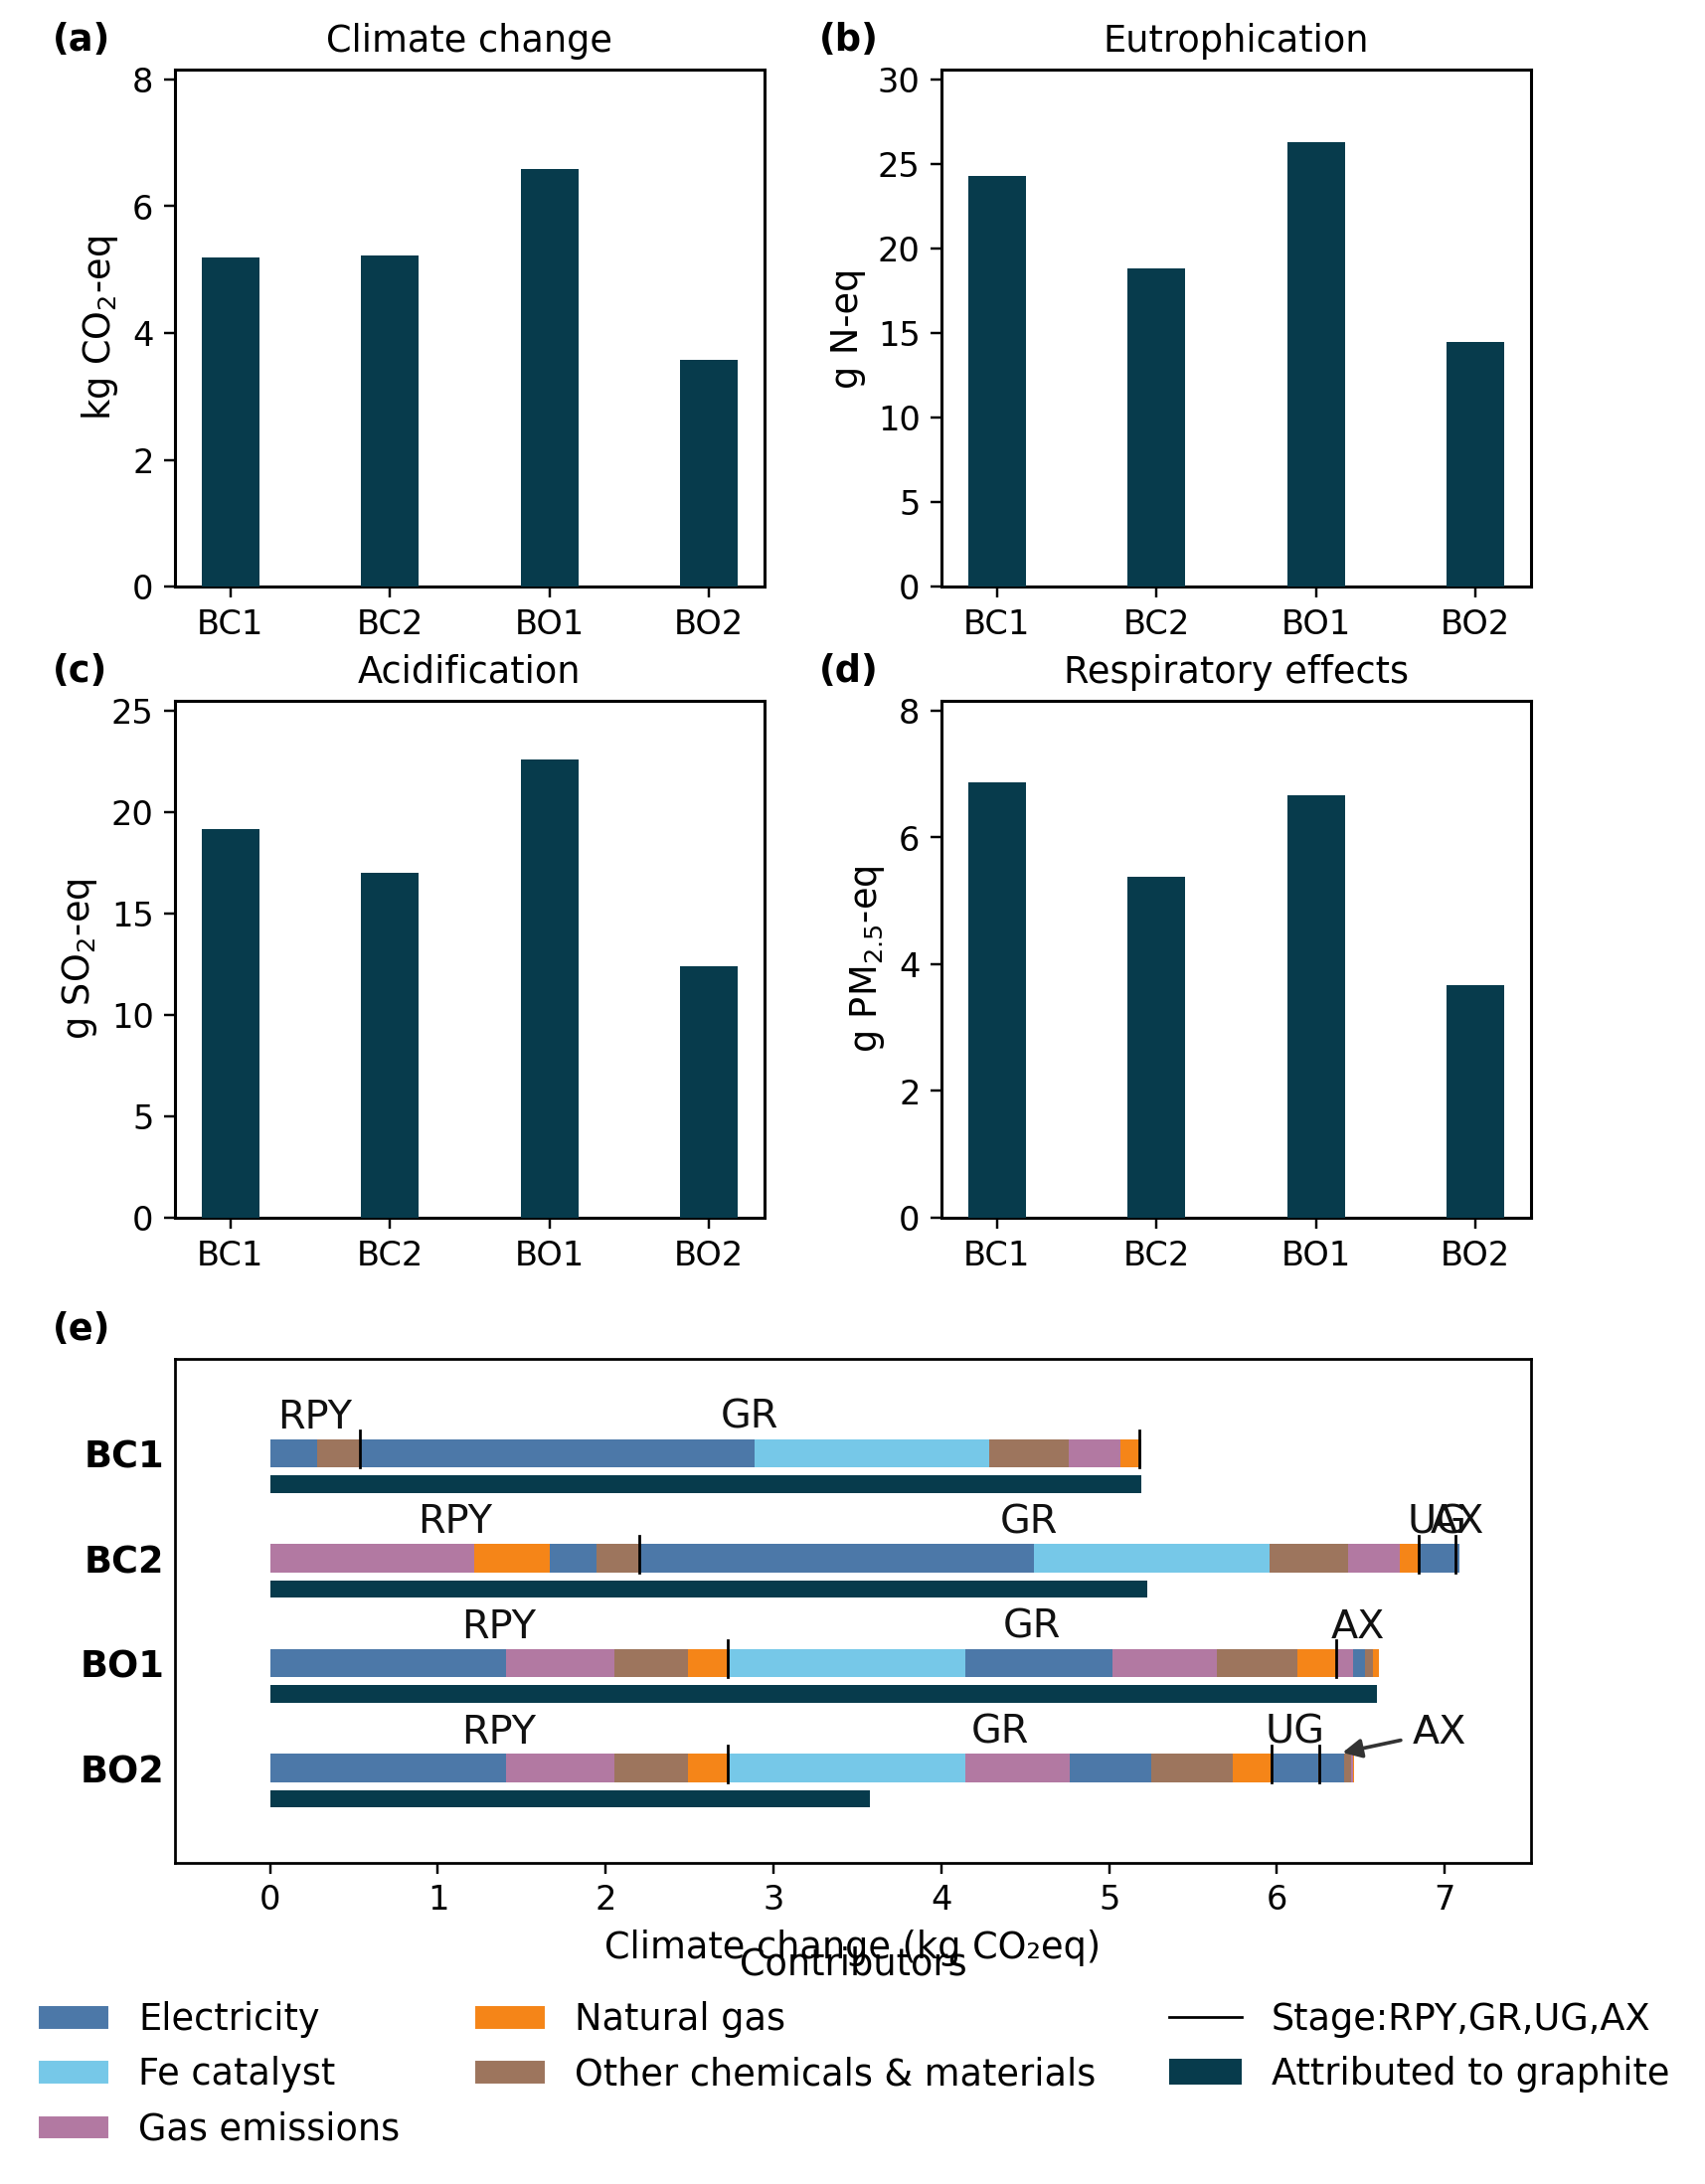

In [8]:
import matplotlib.pyplot as plt
from graphite_sus.plots.lca_main import make_main_lca_figure

fig_lca = make_main_lca_figure()
fig_lca.savefig(OUTPUT_DIR / "figure_lca_main.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Main TEA Figure 3 — exact MSP breakdown + electricity/feedstock frontier

Finance & tax include: net discounted financing cash flows, including construction-period interest (IDC), debt draws, principal and interest repayments, and corporate income taxes.

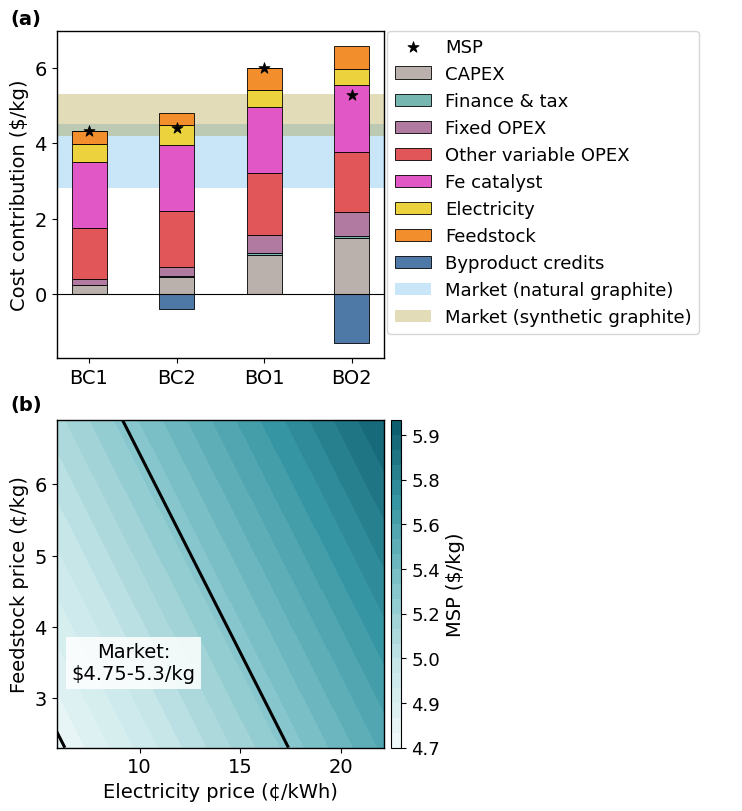

In [9]:
from graphite_sus.plots.tea_figure3 import figure_breakdown_plus_frontier

# Market natural/synthetic bands, synthetic representative price, and the
# frontier comparison band are all read from data/market_reference.csv.
fig_tea = figure_breakdown_plus_frontier(
    tea_cache,
    xtick_labels=("BC1","BC2","BO1","BO2"),
    frontier_scenario="s_o2",
    tea_profile=TEA_PROFILE,
    market_range=(4.75,5.3)
)
fig_tea.savefig(OUTPUT_DIR / "figure3_tea.png", dpi=300, bbox_inches="tight")
plt.show()

The Figure 3 stack is required to satisfy the exact discounted cash-flow identity:

\[
MSP = CAPEX + Finance\&tax + Fixed\ OPEX + Other\ variable\ OPEX
+ Fe + Electricity + Feedstock + Byproduct\ credits.
\]

No residual or “numerical adjustment” bar is permitted.

## 8. Diagnostic MSP waterfalls for all pathways

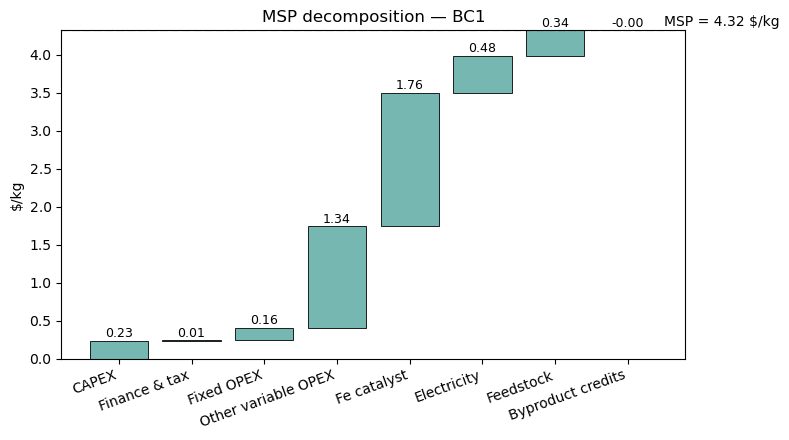

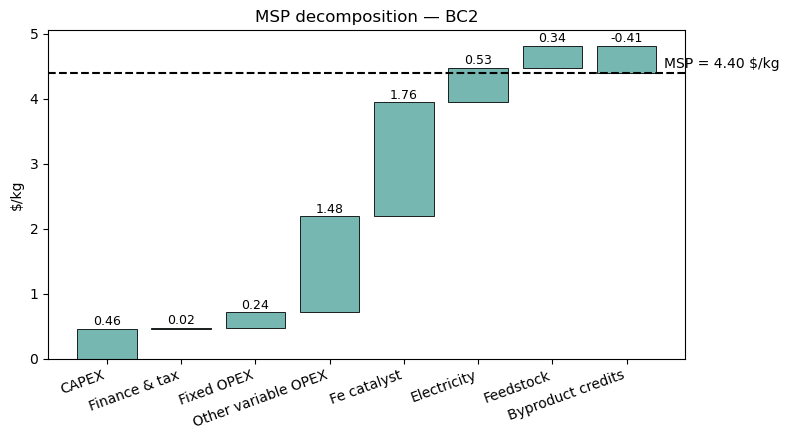

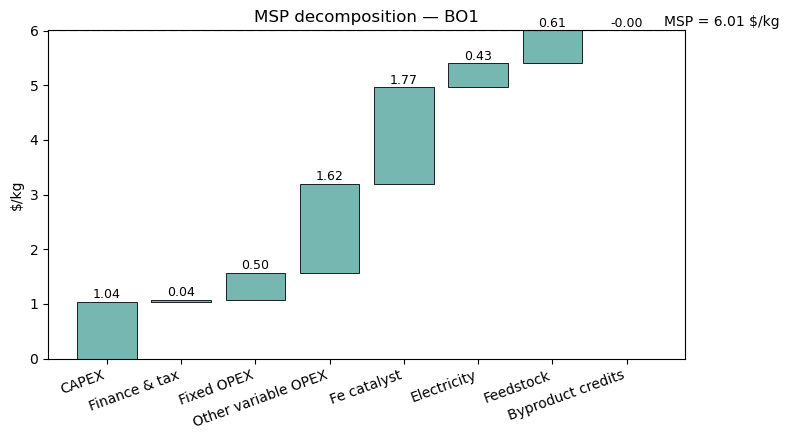

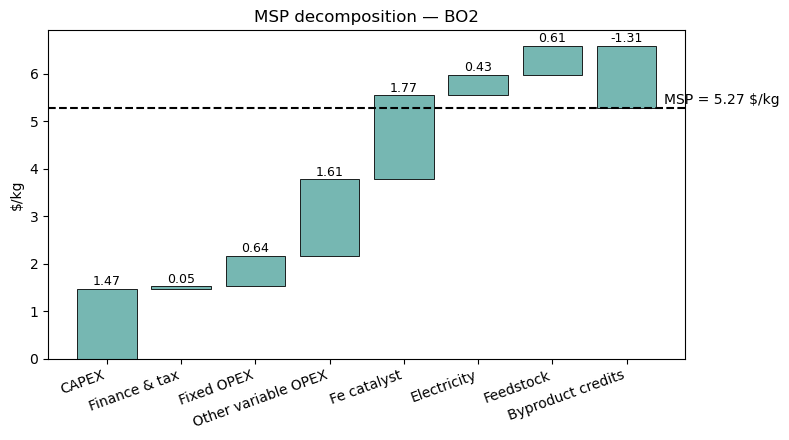

In [10]:
from graphite_sus.plots.tea_figure3 import plot_waterfall_for

for sc, label in [("s_c1","BC1"), ("s_c2","BC2"), ("s_o1","BO1"), ("s_o2","BO2")]:
    fig = plot_waterfall_for(tea_cache[sc], title=f"MSP decomposition — {label}")
    fig.savefig(OUTPUT_DIR / f"waterfall_{label}.png", dpi=300, bbox_inches="tight")
    plt.show()

### Summary of cost item in %

In [11]:
# Exact percentage contribution of each Figure-3 category to MSP
pct_rows = []

for sc, label in [
    ("s_c1", "BC1"),
    ("s_c2", "BC2"),
    ("s_o1", "BO1"),
    ("s_o2", "BO2"),
]:
    item = tea_cache[sc]

    msp = float(item["result"].summary["msp_usd_per_kg"])
    contrib = item["contributions"]

    for category, value in contrib.items():
        pct_rows.append({
            "scenario": sc,
            "pathway": label,
            "category": category,
            "contribution_usd_per_kg": float(value),
            "contribution_pct_of_msp": 100 * float(value) / msp,
        })

tea_contribution_pct = pd.DataFrame(pct_rows)

display(
    tea_contribution_pct.pivot(
        index="category",
        columns="pathway",
        values="contribution_pct_of_msp",
    ).round(1)
)

tea_contribution_pct.to_csv(
    OUTPUT_DIR / "deterministic_tea_contribution_percent.csv",
    index=False,
)

pathway,BC1,BC2,BO1,BO2
category,,,,
Byproduct credits,-0.0,-9.4,-0.0,-24.9
CAPEX,5.3,10.4,17.3,27.9
Electricity,11.2,11.9,7.2,8.1
Fe catalyst,40.7,40.0,29.5,33.6
Feedstock,7.9,7.8,10.1,11.5
Finance & tax,0.2,0.4,0.6,1.0
Fixed OPEX,3.7,5.4,8.3,12.2
Other variable OPEX,31.0,33.6,27.1,30.6


In [12]:
summary_rows = []

for sc, label in [
    ("s_c1", "BC1"),
    ("s_c2", "BC2"),
    ("s_o1", "BO1"),
    ("s_o2", "BO2"),
]:
    item = tea_cache[sc]
    msp = float(item["result"].summary["msp_usd_per_kg"])
    c = item["contributions"]

    summary_rows.append({
        "pathway": label,
        "MSP ($/kg)": msp,
        "Fe + other variable OPEX (%)":
            100 * (c["Fe catalyst"] + c["Other variable OPEX"]) / msp,
        "Electricity + feedstock (%)":
            100 * (c["Electricity"] + c["Feedstock"]) / msp,
        "CAPEX (%)":
            100 * c["CAPEX"] / msp,
        "Fixed OPEX (%)":
            100 * c["Fixed OPEX"] / msp,
        "Byproduct credit (% of MSP)":
            100 * c["Byproduct credits"] / msp,
    })

tea_grouped_pct = pd.DataFrame(summary_rows)
display(tea_grouped_pct.round(1))

,pathway,MSP ($/kg),Fe + other variable OPEX (%),Electricity + feedstock (%),CAPEX (%),Fixed OPEX (%),Byproduct credit (% of MSP)
0,BC1,4.3,71.7,19.1,5.3,3.7,-0.0
1,BC2,4.4,73.5,19.7,10.4,5.4,-9.4
2,BO1,6.0,56.6,17.3,17.3,8.3,-0.0
3,BO2,5.3,64.2,19.6,27.9,12.2,-24.9


In [13]:
# Check the values for financing and taxes
for sc, item in tea_cache.items():
    res = item["result"]
    cf = res.cashflows.copy()

    r = float(res.summary["target_irr"])
    t = cf.index.to_numpy(dtype=float)
    disc = (1.0 + r) ** (-t)

    def pv(col):
        return float((cf[col].to_numpy(dtype=float) * disc).sum())

    print(f"\n{sc}")
    print(f"PV loan draws:       {pv('loan_draws')/1e6: .3f} M$")
    print(f"PV principal:        {pv('loan_principal_pmt')/1e6: .3f} M$")
    print(f"PV interest:         {pv('loan_interest_pmt')/1e6: .3f} M$")
    print(f"PV tax:              {pv('tax')/1e6: .3f} M$")

    finance_tax_pv = (
        pv("loan_draws")
        + pv("loan_principal_pmt")
        + pv("loan_interest_pmt")
        + pv("tax")
    )

    print(f"PV finance + tax:    {finance_tax_pv/1e6: .3f} M$")


s_c1
PV loan draws:        180.530 M$
PV principal:        -97.353 M$
PV interest:         -56.720 M$
PV tax:              -22.491 M$
PV finance + tax:     3.966 M$

s_c2
PV loan draws:        360.574 M$
PV principal:        -194.443 M$
PV interest:         -113.288 M$
PV tax:              -41.921 M$
PV finance + tax:     10.921 M$

s_o1
PV loan draws:        460.803 M$
PV principal:        -248.493 M$
PV interest:         -144.779 M$
PV tax:              -52.137 M$
PV finance + tax:     15.394 M$

s_o2
PV loan draws:        654.529 M$
PV principal:        -352.962 M$
PV interest:         -205.645 M$
PV tax:              -73.773 M$
PV finance + tax:     22.149 M$


### electricity price-feedstock combination 

In [14]:
import numpy as np

from graphite_sus.plots.tea_figure3 import msp_surface_two_prices
from graphite_sus.market_reference import get_market_ranges
from graphite_sus.electricity_reference import get_electricity_uncertainty_range

# Use exactly the same ranges as Figure 3b
elec_lo, elec_hi = get_electricity_uncertainty_range()
elec_axis = np.linspace(elec_lo, elec_hi, 61)

feed_axis = np.linspace(0.023, 0.069, 61)   # $/kg feedstock

# Recalculate the exact BO2 MSP surface used by Figure 3b
Z_bo2 = msp_surface_two_prices(
    tea_cache["s_o2"],
    elec_axis,
    feed_axis,
    tea_profile=TEA_PROFILE,
)

# Authoritative upper bound of market synthetic graphite
synthetic_upper = get_market_ranges()["synthetic"][1]

# Fraction of price combinations where BO2 is competitive
competitive = Z_bo2 <= synthetic_upper

n_competitive = competitive.sum()
n_total = competitive.size
pct_competitive = 100 * competitive.mean()

print(f"Synthetic graphite upper bound: ${synthetic_upper:.2f}/kg")
print(f"Competitive combinations: {n_competitive}/{n_total}")
print(f"BO2 MSP <= synthetic upper bound in {pct_competitive:.1f}% of combinations.")

Synthetic graphite upper bound: $5.30/kg
Competitive combinations: 1693/3721
BO2 MSP <= synthetic upper bound in 45.5% of combinations.


## 9. Optional payback diagnostic

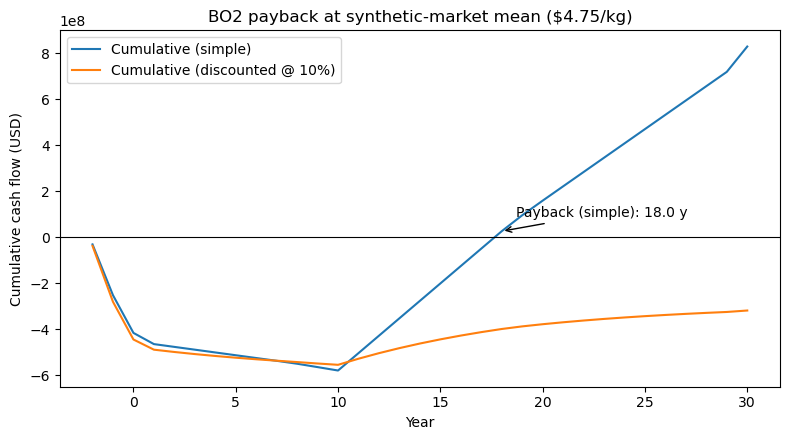

In [15]:
from graphite_sus.plots.tea_figure3 import plot_payback

RUN_PAYBACK = True
if RUN_PAYBACK:
    synthetic_market_mean = get_market_mean("synthetic")
    fig, payback_result = plot_payback(
        tea_cache["s_o2"],
        market_price=synthetic_market_mean,
        tea_profile=TEA_PROFILE,
        title=f"BO2 payback at synthetic-market mean (${synthetic_market_mean:.2f}/kg)",
    )
    fig.savefig(OUTPUT_DIR / "payback_BO2_market_mean.png", dpi=300, bbox_inches="tight")
    plt.show()

## 10. SI: single-impact stage/category breakdown

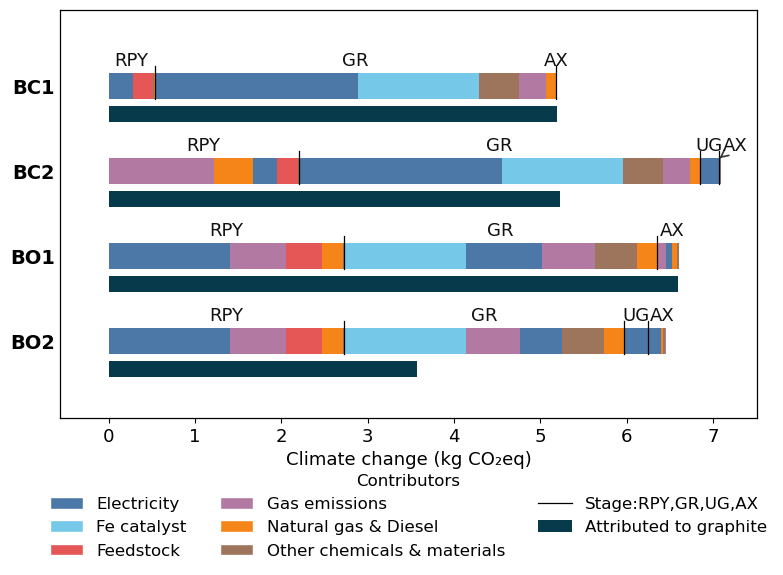

In [16]:
from graphite_sus.plots.lca_stage_breakdown import make_stage_breakdown

fig_stage, tables_stage = make_stage_breakdown()
fig_stage.savefig(OUTPUT_DIR / "si_stage_breakdown_gwp.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. SI: allocation-method overview

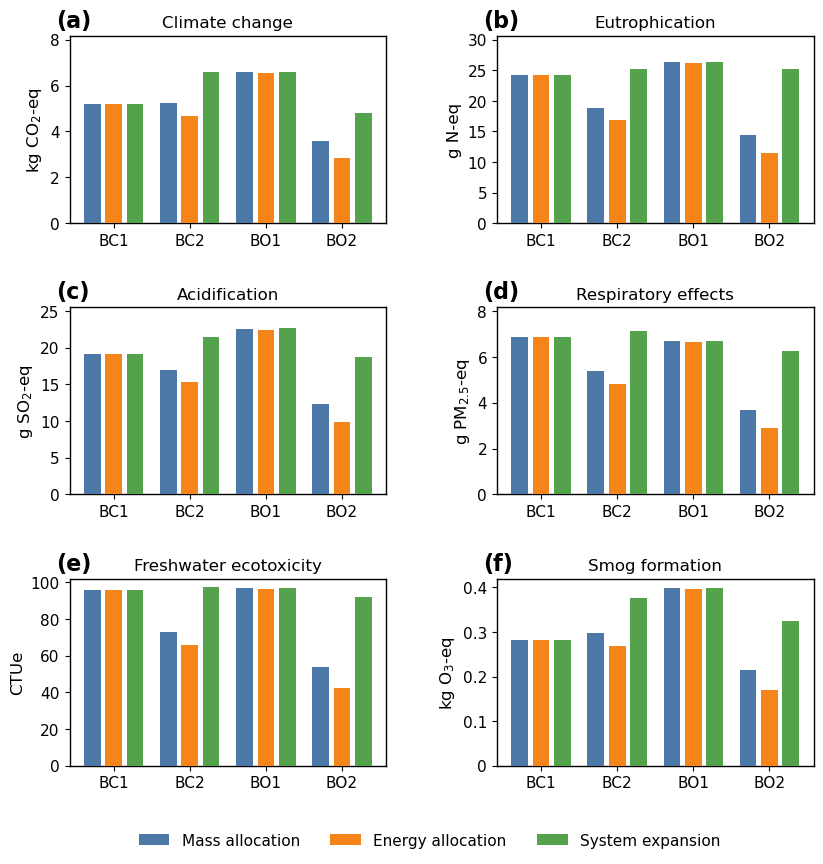

In [17]:
import importlib
import graphite_sus.plots.lca_main as lca_main
import graphite_sus.plots.lca_allocation as lca_allocation


fig_alloc, axs_alloc = lca_allocation.make_allocation_overview()

fig_alloc.savefig(
    OUTPUT_DIR / "si_allocation_overview.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 12. SI: extended impact overview

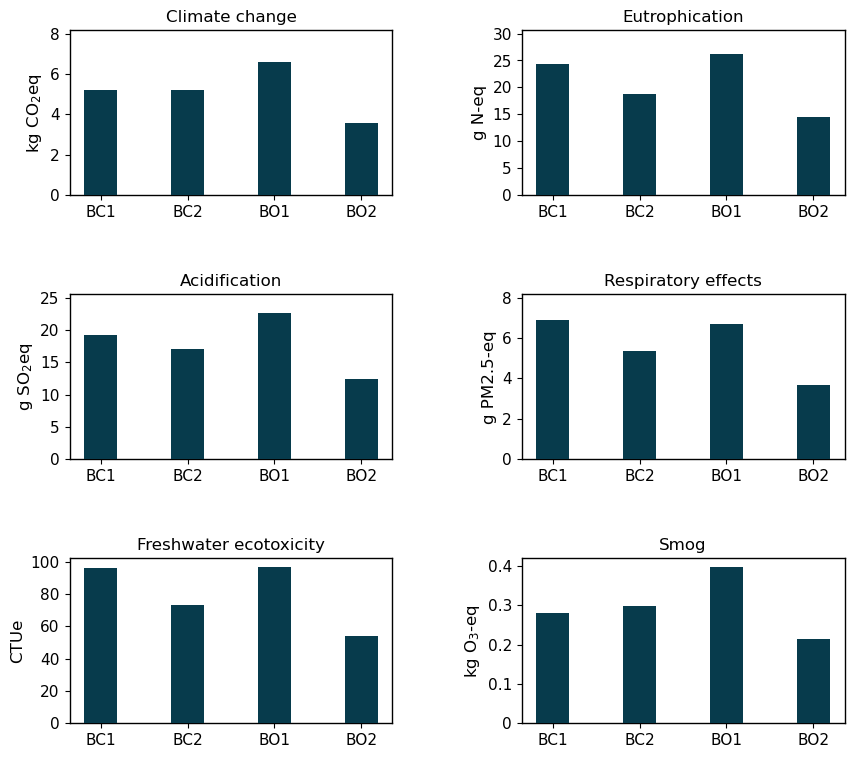

In [18]:
import matplotlib.pyplot as plt

from graphite_sus.plots.lca_extended import make_extended_lca_overview


fig_ext, axs_ext = make_extended_lca_overview()

fig_ext.savefig(
    OUTPUT_DIR / "si_extended_impacts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 13. SI: six-impact stage/category mosaic

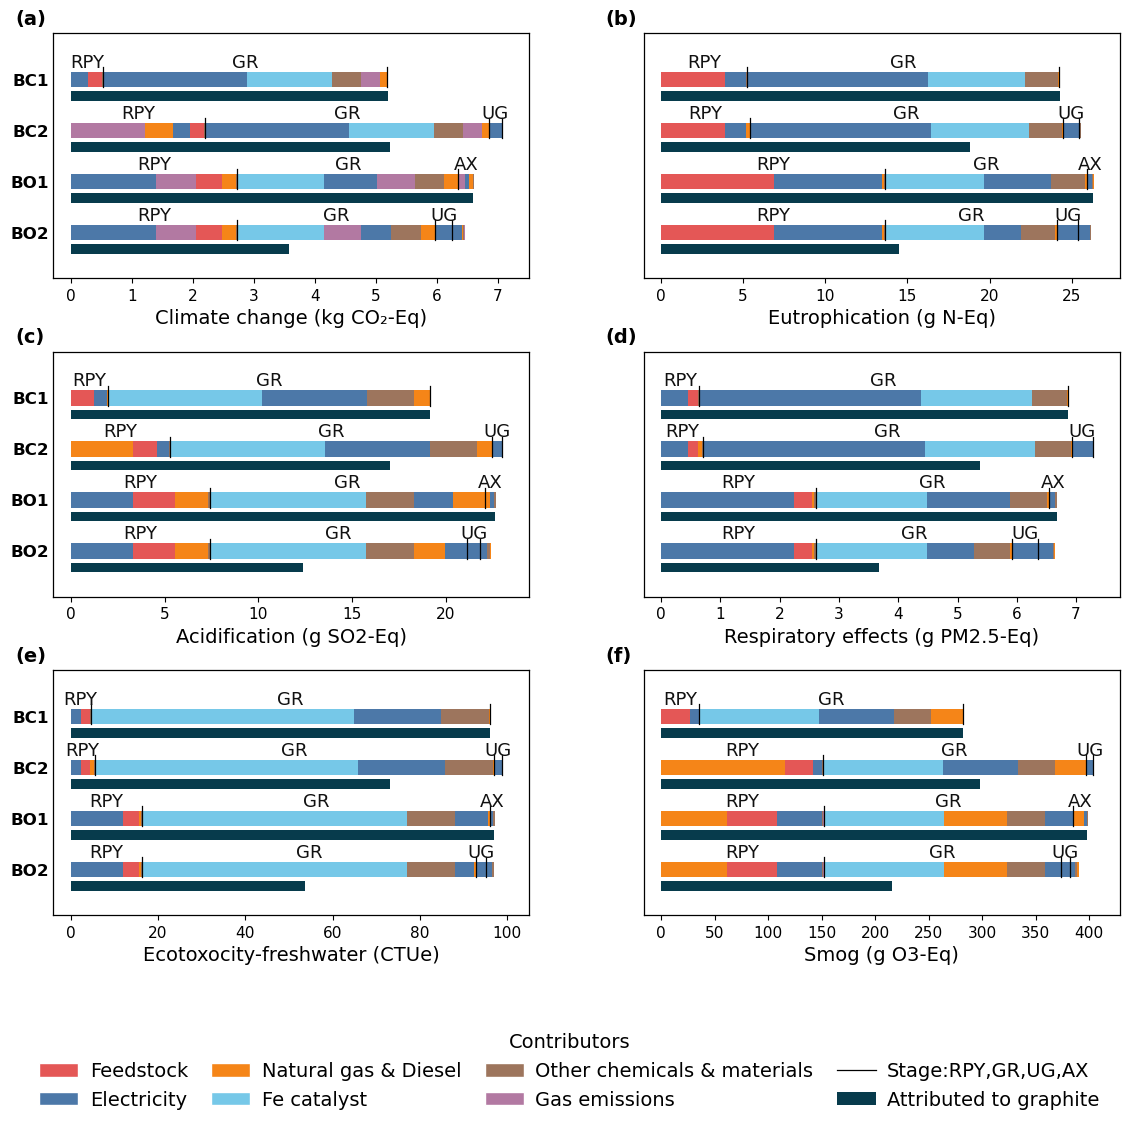

In [19]:
from graphite_sus.plots.lca_multiimpact import make_multiimpact_mosaic

fig_multi, axs_multi = make_multiimpact_mosaic()
fig_multi.savefig(OUTPUT_DIR / "si_multiimpact_breakdown.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Numerical contributor-share audit behind the LCA plots

In [20]:
from graphite_sus.plots.lca_contributors import compute_category_shares_for_methods
from graphite_sus.plots.lca_multiimpact import DEFAULT_MULTIIMPACT_METHODS
import bw2data as bd

import importlib

import graphite_sus.plots.lca_contributors as lca_contributors
importlib.reload(lca_contributors)

from graphite_sus.plots.lca_contributors import (
    compute_category_shares_for_methods,
)

lca_db = bd.Database("graphite_system")
sys_acts = [
    lca_db.get("system::graphite_prod_char::graphtz_char"),
    lca_db.get("system::graphite_prod_char::graphtz_char_alloc"),
    lca_db.get("system::graphite_prod_char::graphtz_coke"),
    lca_db.get("system::graphite_prod_char::graphtz_coke_alloc"),
]
titles = ["BC1","BC2","BO1","BO2"]


shares, _ = compute_category_shares_for_methods(
    sys_acts,
    titles,
    DEFAULT_MULTIIMPACT_METHODS,
    target_categories=("Electricity", "Feedstock", "Fe catalyst"),
    use_display_formula=False,
    positive_only=True,
)
display(shares)
shares.to_csv(OUTPUT_DIR / "lca_contributor_shares.csv", index=False)

,impact_label,impact_slug,pathway,category,share,share_pct
0,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC1,Electricity,0.507192,50.719237
1,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC1,Feedstock,0.045428,4.542779
2,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC1,Fe catalyst,0.269840,26.984014
3,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC2,Electricity,0.403883,40.388322
4,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC2,Feedstock,0.033275,3.327467
...,...,...,...,...,...,...
67,Smog formation,TRACI_v2_1__photochemical_oxidant_formation__m...,BO1,Feedstock,0.119131,11.913146
68,Smog formation,TRACI_v2_1__photochemical_oxidant_formation__m...,BO1,Fe catalyst,0.282519,28.251872
69,Smog formation,TRACI_v2_1__photochemical_oxidant_formation__m...,BO2,Electricity,0.177671,17.767118
70,Smog formation,TRACI_v2_1__photochemical_oxidant_formation__m...,BO2,Feedstock,0.121890,12.189041


In [21]:
shares, _ = compute_category_shares_for_methods(
    sys_acts,
    titles,
    DEFAULT_MULTIIMPACT_METHODS,
    target_categories=("Natural gas & Diesel", "Feedstock", "Gas emissions"),
    use_display_formula=False,
    positive_only=True,
)
display(shares)

,impact_label,impact_slug,pathway,category,share,share_pct
0,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC1,Natural gas & Diesel,0.025500,2.550007
1,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC1,Feedstock,0.045428,4.542779
2,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC1,Gas emissions,0.059307,5.930709
3,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC2,Natural gas & Diesel,0.081992,8.199210
4,Climate change,IPCC_2021__climate_change__global_warming_pote...,BC2,Feedstock,0.033275,3.327467
...,...,...,...,...,...,...
67,Smog formation,TRACI_v2_1__photochemical_oxidant_formation__m...,BO1,Feedstock,0.119131,11.913146
68,Smog formation,TRACI_v2_1__photochemical_oxidant_formation__m...,BO1,Gas emissions,0.000140,0.014048
69,Smog formation,TRACI_v2_1__photochemical_oxidant_formation__m...,BO2,Natural gas & Diesel,0.313133,31.313304
70,Smog formation,TRACI_v2_1__photochemical_oxidant_formation__m...,BO2,Feedstock,0.121890,12.189041


## 15. Final acceptance gate and run manifest

In [22]:
# Deterministic LCIA contributor-accounting audit.
# Full exchange-level stacks must reproduce impact__<method> exactly, and
# mass-allocated graphite impacts must not exceed the corresponding system total.
from graphite_sus.plots.lca_main import (
    breakdown_closure_table,
    default_graphite_system_activities,
)
from graphite_sus.plots.lca_multiimpact import DEFAULT_MULTIIMPACT_METHODS

lca_breakdown_audit = breakdown_closure_table(
    default_graphite_system_activities(),
    ["BC1", "BC2", "BO1", "BO2"],
    DEFAULT_MULTIIMPACT_METHODS,
)
lca_breakdown_audit.to_csv(OUTPUT_DIR / "lca_breakdown_closure_audit.csv", index=False)
display(lca_breakdown_audit)

assert bool(lca_breakdown_audit["passes_breakdown_closure"].all())
assert bool(lca_breakdown_audit["allocated_not_larger_than_system"].all())


,impact_slug,pathway,breakdown_total,system_impact,allocated_mass_impact,mass_allocation_fraction,breakdown_delta,passes_breakdown_closure,allocated_not_larger_than_system
0,IPCC_2021__climate_change__global_warming_pote...,BC1,5.191801,5.191801,5.191801,1.000000,0.000000e+00,True,True
1,IPCC_2021__climate_change__global_warming_pote...,BC2,7.088036,7.088036,5.224075,0.737027,8.881784e-16,True,True
2,IPCC_2021__climate_change__global_warming_pote...,BO1,6.608746,6.608746,6.594222,0.997802,-8.881784e-16,True,True
3,IPCC_2021__climate_change__global_warming_pote...,BO2,6.458725,6.458725,3.571573,0.552984,-1.776357e-15,True,True
4,TRACI_v2_1__eutrophication__eutrophication_pot...,BC1,0.024280,0.024280,0.024280,1.000000,3.469447e-18,True,True
5,TRACI_v2_1__eutrophication__eutrophication_pot...,BC2,0.025539,0.025539,0.018823,0.737027,-3.469447e-18,True,True
6,TRACI_v2_1__eutrophication__eutrophication_pot...,BO1,0.026347,0.026347,0.026289,0.997802,-6.938894e-18,True,True
7,TRACI_v2_1__eutrophication__eutrophication_pot...,BO2,0.026202,0.026202,0.014489,0.552984,3.469447e-18,True,True
8,TRACI_v2_1__acidification__acidification_poten...,BC1,0.019165,0.019165,0.019165,1.000000,3.469447e-18,True,True
9,TRACI_v2_1__acidification__acidification_poten...,BC2,0.023059,0.023059,0.016995,0.737027,3.469447e-18,True,True


In [23]:
required_outputs = [
    "figure_lca_main.png",
    "figure3_tea.png",
    "si_stage_breakdown_gwp.png",
    "si_allocation_overview.png",
    "si_extended_impacts.png",
    "si_multiimpact_breakdown.png",
    "lca_breakdown_closure_audit.csv",
]
missing_outputs = [name for name in required_outputs if not (OUTPUT_DIR / name).exists()]

checks = {
    "four_TEA_scenarios": len(tea_cache) == 4,
    "all_IRR_10pct": bool(tea_validation["passes_irr"].all()),
    "all_MSP_decompositions_close": bool(tea_validation["passes_closure"].all()),
    "native_units_valid": int((unit_counts > 1).sum()) == 0,
    "national_electricity_matches_reference": abs(elec - US_INDUSTRIAL_ELECTRICITY_2025_USD_PER_KWH) < 1e-12,
    "electricity_baseline_inside_uncertainty_range": elec_lo <= elec <= elec_hi,
    "market_reference_loaded": set(market_ranges) == {"natural", "synthetic"},
    "netl_fuel_reference_applied": (not fuel_ef_audit.empty) and bool(fuel_ef_audit["passed"].all()),
    "electricity_lcia_reference_verified": (not electricity_ef_audit.empty) and bool(electricity_ef_audit["passed"].all()),
    "all_LCA_breakdowns_close": bool(lca_breakdown_audit["passes_breakdown_closure"].all()),
    "mass_allocated_impacts_not_larger_than_system": bool(lca_breakdown_audit["allocated_not_larger_than_system"].all()),
    "all_required_figures_written": not missing_outputs,
}
for name, passed in checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")

manifest = {
    "project_name": PROJECT_NAME,
    "rebuild_databases": REBUILD_DATABASES,
    "tea_profile": TEA_PROFILE,
    "electricity_mode": ELECTRICITY_MODE,
    "electricity_usd_per_kwh": elec,
    "electricity_references": electricity_reference_manifest(),
    "market_references": market_reference_manifest(),
    "fuel_ef_reference": fuel_reference_manifest(),
    "electricity_ef_reference": electricity_ef_reference_manifest(),
    "lci_workbook": str(LCI_XLSX),
    "tea_workbook": str(TEA_XLSX),
    "checks": checks,
    "missing_outputs": missing_outputs,
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2))
assert all(checks.values()), manifest
print("DETERMINISTIC WORKFLOW ACCEPTED")


four_TEA_scenarios: PASS
all_IRR_10pct: PASS
all_MSP_decompositions_close: PASS
native_units_valid: PASS
national_electricity_matches_reference: PASS
electricity_baseline_inside_uncertainty_range: PASS
market_reference_loaded: PASS
netl_fuel_reference_applied: PASS
electricity_lcia_reference_verified: PASS
all_LCA_breakdowns_close: PASS
mass_allocated_impacts_not_larger_than_system: PASS
all_required_figures_written: PASS
DETERMINISTIC WORKFLOW ACCEPTED
